# D2.2-2: Analysing Sentinel-5P CO Data with openEO

This notebook demonstrates how to use the openEO API to
process Sentinel-5P Carbon Monoxide (CO) observations on
the EODC openEO backend.

Unlike traditional workflows where the complete dataset
is downloaded and processed locally, openEO allows the
processing to be executed close to the data source.

The workflow covers:

- connecting to the openEO backend,
- exploring available collections,
- loading Sentinel-5P CO data,
- defining server-side processing steps,
- executing a batch job,
- downloading the results,
- exploring the generated Zarr dataset,
- visualising the processed data.



## Environment Setup

This notebook requires the following Python packages:

- openeo
- zarr

Suggested Pixi environment:

```bash
pixi add \
  python>=3.11 \
  openeo \
  zarr \
  matplotlib \
  ipykernel
```

Notes:

- The notebook was tested with Python 3.14.
- Processing is executed on the openEO backend.
- Only the resulting product is downloaded locally.

## openEO Account and Authentication

The openEO Python client is used to connect to EODC's
openEO API.

An openEO account is required to execute processing jobs.
During the authentication step, a browser window may open
and the user will be prompted to log in via OpenID Connect
(OIDC).

If you do not yet have an account, you can register for a
free openEO account. Additional information is available at:

https://docs.openeo.cloud/join/free_trial.html

After authentication, the openEO backend can be used to
discover datasets, build processing workflows and execute
Earth observation analyses directly on the server side.


## Import Required Packages

We first import the Python packages required for connecting
to openEO, handling Zarr data and visualising the results.


In [1]:
import openeo
import xarray as xr
import zarr
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import shutil
import zipfile
import os


## Connect to the openEO Backend

We establish a connection to the EODC openEO backend and
authenticate via OpenID Connect (OIDC).

The authentication process opens a browser window where
the user can log in using their openEO account. Once
authenticated, the connection can be used to discover
collections, construct process graphs and execute batch
processing jobs.


In [2]:
backend_url = "https://openeo-dev.eodc.eu/openeo/1.2.0"

connection = openeo.connect(backend_url)
connection.authenticate_oidc()

print("Connected successfully.")
print(connection)

Authenticated using refresh token.
Connected successfully.
<Connection to 'https://openeo-dev.eodc.eu/openeo/1.2.0/' with OidcBearerAuth>


## Explore Available Collections

openEO provides a catalogue of available Earth observation
datasets. We inspect the available collections and identify
the Sentinel-5P product.


In [3]:
collections = connection.list_collections()

print(f"Number of collections: {len(collections)}")

for col in collections:
    col_id = col["id"].lower()
    if any(key in col_id for key in ["s5p", "sentinel5p", "sentinel-5p", "sentinel_5p"]):
        print(col["id"])


Number of collections: 21
SENTINEL5P_DAILY_AUT


## Inspect Sentinel-5P Collection Metadata

We retrieve metadata for the Sentinel-5P collection used
in this example.


In [4]:
collection_id = "SENTINEL5P_DAILY_AUT"

metadata = connection.describe_collection(collection_id)

print("Collection:")
print(metadata["id"])

print("\nDescription:")
print(metadata.get("description", "No description available"))


Collection:
SENTINEL5P_DAILY_AUT

Description:
Daily mean atmospheric composition dataset derived from Sentinel-5P/TROPOMI Level-2 swath products, regridded to a common spatial grid and stored in Zarr format.


## Define the Analysis Domain

We specify:

- a geographic region of interest,
- a temporal extent,
- the Sentinel-5P collection.

The study area covers a small region in Austria.


In [5]:
spatial_extent = {
    "west": 15,
    "east": 17,
    "south": 47,
    "north": 49,
    "crs": "EPSG:4326"
}

temporal_extent = [
    "2019-01-01",
    "2025-12-31"
]

## Load Sentinel-5P CO Data

We load the Sentinel-5P CO dataset from the backend using
the selected spatial and temporal extents.

At this stage no actual processing is executed. Instead,
openEO creates a process graph describing the workflow.


In [6]:
cube = connection.load_collection(
    collection_id,
    spatial_extent=spatial_extent,
    temporal_extent=temporal_extent
)

cube


## Build the Processing Workflow

One of the key strengths of openEO is server-side
processing. Rather than downloading all observations,
we define a process graph that is executed directly on
the backend.

Processing steps:

1. Aggregate daily observations to monthly means.
2. Reduce the spatial dimensions using a mean reducer.
3. Save the result as Zarr.

The final product is therefore a compact monthly time
series of CO concentrations.


In [7]:
cube = cube.aggregate_temporal_period(
    period="month",
    dimension="time",
    reducer="mean"
)

cube = cube.reduce_dimension(
    dimension="x",
    reducer="mean"
)

cube = cube.reduce_dimension(
    dimension="y",
    reducer="mean"
)

cube = cube.save_result(format="zarr")


## Inspect the Process Graph

The process graph describes all operations that will be
executed by the backend.

This allows users to verify and reproduce the workflow.


In [8]:
cube.print_json()

{
  "process_graph": {
    "loadcollection1": {
      "process_id": "load_collection",
      "arguments": {
        "id": "SENTINEL5P_DAILY_AUT",
        "spatial_extent": {
          "west": 15,
          "east": 17,
          "south": 47,
          "north": 49,
          "crs": "EPSG:4326"
        },
        "temporal_extent": [
          "2019-01-01",
          "2025-12-31"
        ]
      }
    },
    "aggregatetemporalperiod1": {
      "process_id": "aggregate_temporal_period",
      "arguments": {
        "data": {
          "from_node": "loadcollection1"
        },
        "dimension": "time",
        "period": "month",
        "reducer": {
          "process_graph": {
            "mean1": {
              "process_id": "mean",
              "arguments": {
                "data": {
                  "from_parameter": "data"
                }
              },
              "result": true
            }
          }
        }
      }
    },
    "reducedimension1": {
      "process_id

## Submit a Batch Job

We submit the process graph to the backend as a batch job.

Batch processing is recommended for larger Earth
observation datasets and computationally intensive tasks


In [9]:
job = cube.create_job(
    title="Sentinel5P-CO"
)

print("Job created:")
print(job.job_id)

Preflight process graph validation raised: [404] Load call not available for SENTINEL5P_DAILY_AUT


Job created:
e3d32dda-97f9-4cec-bb47-d446a8849e44


## Start Processing

The batch job is now sent to the backend infrastructure.

Processing is executed remotely. Depending on the amount
of data and available resources, execution may take
some time.

In [10]:
job.start_job()

print("Job started.")

job

Job started.


<BatchJob job_id='e3d32dda-97f9-4cec-bb47-d446a8849e44'>

## Monitor Job Status

We periodically check the status of the submitted job.

Typical states:

- created
- queued
- running
- finished
- error

In [11]:
status = job.status()

print("Current status:")
print(status)

Current status:
queued


## Wait Until Processing Is Finished

In production workflows one would typically poll the
job status until completion.


In [12]:
import time

while job.status() not in ["finished", "error"]:
    time.sleep(30)
    print(job.status())

running
running
running
finished



## Retrieve Job Results

Once the batch job has finished, we obtain the result
metadata and the downloadable assets generated by the
openEO backend.


In [13]:
results = job.get_results()

metadata = results.get_metadata()

print("Job metadata:")
metadata


Job metadata:


{'stac_version': '1.0.0',
 'stac_extensions': [],
 'type': 'Collection',
 'id': 'e3d32dda-97f9-4cec-bb47-d446a8849e44',
 'description': '',
 'deprecated': False,
 'license': 'other',
 'providers': [],
 'extent': {'spatial': {'bbox': [[15.059117,
     46.940735,
     15.059117,
     46.940735]]},
  'temporal': {'interval': [['2026-07-09T16:47:48.058075Z',
     '2026-07-09T16:47:48.058075Z']]}},
 'links': [{'rel': 'self',
   'href': 'https://openeo-dev.eodc.eu/openeo/1.2.0/jobs/e3d32dda-97f9-4cec-bb47-d446a8849e44/results',
   'type': 'application/json'},
  {'rel': 'root',
   'href': 'https://openeo-dev.eodc.eu/openeo/1.2.0/jobs/e3d32dda-97f9-4cec-bb47-d446a8849e44/results',
   'type': 'application/json'},
  {'rel': 'item',
   'href': 'https://openeo-dev.eodc.eu/openeo/1.2.0/jobs/e3d32dda-97f9-4cec-bb47-d446a8849e44/results',
   'type': 'application/geo+json'},
  {'rel': 'canonical',
   'href': 'https://openeo-dev.eodc.eu/openeo/1.2.0/jobs/e3d32dda-97f9-4cec-bb47-d446a8849e44/results?Exp

## Inspect Available Assets

The result object contains one or more downloadable assets.

In [14]:
results

<JobResults for job 'e3d32dda-97f9-4cec-bb47-d446a8849e44'>

## Download Results

The result generated by the openEO backend is downloaded
to the local environment.

Since only files can be downloaded, the Zarr dataset is
delivered as a ZIP archive, even though it may initially
appear with a .zarr extension.


In [16]:
download_directory = "/tmp/download"

Path(download_directory).mkdir(exist_ok=True)

results.download_files(download_directory)

print("Download completed.")

Download completed.


## Inspect Downloaded Files

We inspect the downloaded directory and identify the
generated result assets.

In [17]:
for file in os.listdir(download_directory):
    print(file)

job-results.json
openeo_result.zarr


## Prepare the Zarr Dataset

Some openEO backends may return the Zarr archive as a ZIP
file. If necessary we rename and extract the archive.

In [18]:
source_zarr = Path(download_directory) / "openeo_result.zarr"

if source_zarr.exists():

    zip_file = Path(download_directory) / "openeo_result.zip"

    shutil.move(source_zarr, zip_file)

    with zipfile.ZipFile(zip_file, "r") as zf:
        zf.extractall(source_zarr)

    print("Archive extracted.")

Archive extracted.


## Open the Result Dataset

The downloaded result is stored in cloud-native Zarr
format.

Zarr is widely used for scalable Earth observation
workflows and enables efficient access to large
multidimensional datasets.

In [19]:
zarr_path = Path(download_directory) / "openeo_result.zarr"

root = zarr.open_group(zarr_path, mode="r")

print(root.tree())

/
├── carbonmonoxide_total_column (1, 1, 84, 3) float32
├── carbonmonoxide_total_column_n (1, 1, 84, 3) float32
├── qa_threshold (3,) float64
├── spatial_ref () int64
├── time (84,) int64
├── x (1,) float64
└── y (1,) float64

## Inspect Available QA Thresholds

The result contains several time series corresponding to
different quality assurance (QA) threshold values.

We inspect the available thresholds before visualising
the Carbon Monoxide data.

In [20]:
qa_thresholds = root["qa_threshold"][:]

print("QA thresholds:")
print(qa_thresholds)

QA thresholds:
[0.   0.5  0.75]


## Inspect the Carbon Monoxide Variable

The aggregated CO values are stored in the variable
'carbonmonoxide_total_column'.

We inspect the shape, data type and metadata of the
variable generated by the backend.

In [21]:
co = root["carbonmonoxide_total_column"]

print("Shape:", co.shape)
print("Data type:", co.dtype)

print("\nAttributes:")

for key, value in co.attrs.items():
    print(f"{key}: {value}")

Shape: (1, 1, 84, 3)
Data type: float32

Attributes:
coordinates: spatial_ref
_FillValue: AAAAAAAA+H8=


## Load Data into Memory

The backend already performed:

- temporal aggregation (monthly means)
- spatial aggregation (domain average)

Therefore only a small analysis-ready dataset remains.

In [22]:
co_values = co[:]

print("Array shape:", co_values.shape)

Array shape: (1, 1, 84, 3)


## Visualise the Monthly CO Time Series

The final dimension corresponds to different QA threshold
values. We therefore plot one time series for each
threshold.

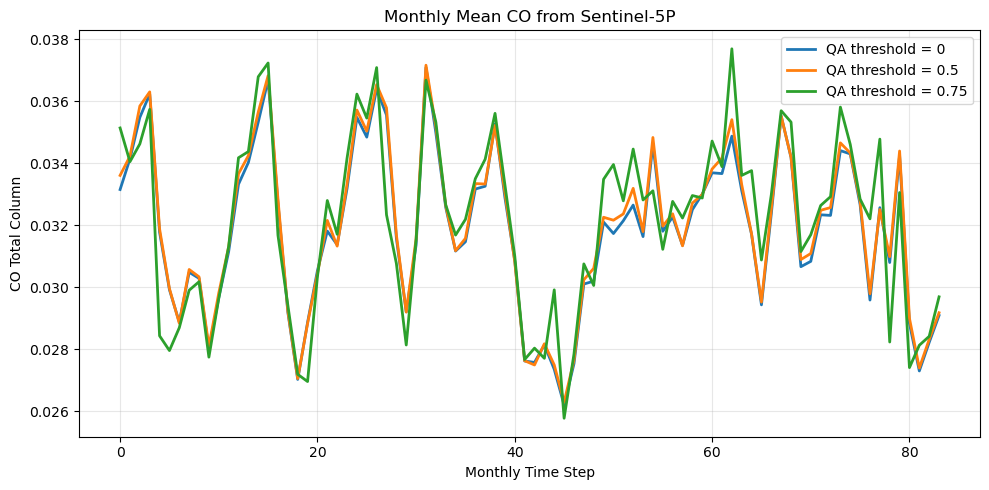

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Original shape:
# (1, 1, time, qa_threshold)

co_ts = np.squeeze(co_values)

fig, ax = plt.subplots(figsize=(10, 5))

for i, qa in enumerate(qa_thresholds):
    ax.plot(
        co_ts[:, i],
        linewidth=2,
        label=f"QA threshold = {qa:g}"
    )

ax.set_title("Monthly Mean CO from Sentinel-5P")
ax.set_xlabel("Monthly Time Step")
ax.set_ylabel("CO Total Column")

ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()


## Basic Statistics

We compute a few summary statistics for each QA threshold.

In [24]:
for i, qa in enumerate(qa_thresholds):

    values = co_ts[:, i]

    print(f"\nQA threshold = {qa:g}")

    print("Minimum:", float(np.nanmin(values)))
    print("Maximum:", float(np.nanmax(values)))
    print("Mean:   ", float(np.nanmean(values)))
    print("Std Dev:", float(np.nanstd(values)))



QA threshold = 0
Minimum: 0.026195351034402847
Maximum: 0.03709849342703819
Mean:    0.03187783062458038
Std Dev: 0.0025409788358956575

QA threshold = 0.5
Minimum: 0.02628299593925476
Maximum: 0.03716949000954628
Mean:    0.03201892971992493
Std Dev: 0.00258468184620142

QA threshold = 0.75
Minimum: 0.02576778084039688
Maximum: 0.03769916296005249
Mean:    0.03214952349662781
Std Dev: 0.002829729812219739


## Interpretation

The downloaded dataset contains monthly aggregated CO
values for multiple quality assurance (QA) thresholds.

The three curves show how different quality filtering
criteria affect the resulting time series. Stricter QA
thresholds retain only observations with higher quality,
which can lead to small differences in the aggregated CO
values.

The example demonstrates how openEO can perform both the
filtering and aggregation steps directly on the backend.
Instead of downloading the complete Sentinel-5P archive,
only a compact analysis-ready product needs to be
transferred to the user.

This reduces data transfer requirements and simplifies
large-scale Earth observation analyses.


## Conclusion

In this notebook we used the EODC openEO backend to
process Sentinel-5P Carbon Monoxide observations.

The workflow demonstrated:

- connecting to an openEO backend,
- discovering available datasets,
- defining server-side processing workflows,
- executing a batch job,
- downloading the generated result,
- exploring cloud-native Zarr outputs,
- analysing monthly CO time series.

The example highlights the advantages of openEO for
scalable and reproducible Earth observation workflows by
moving computation close to the data and delivering
compact analysis-ready products to the user.
